# S-inhibition detector — GPT-2 small validation

**Phase 1.3 deliverable (i).** Validate the path-patching S-inhibition detector (HYPOTHESIS.md §S-1 through §S-4) against Wang 2023's published S-Inhibition heads `{(7,3), (7,9), (8,6), (8,10)}` on GPT-2 small.

**Locked design** (full grilling rationale in NOTES.md *'2026-05-05 — Phase 1.3 grilling: locked design (Q1-Q10)'*):
- Detector method: Wang-style path-patching with frozen paths (Goldowsky-Dill 2023). Receiver = Name Mover attention pattern.
- Corruption: ABC at position-3-only (replace n3 with a fresh name C ∉ {IO, S}).
- NM identification: component-DLA top-4 in each model (k=4 fixed). Wang's published NMs are *not* used as ground truth.
- Receiver scalar (sign-corrected per §S-4):
  `Δ_h = mean over k=4 NMs of [(patched−clean) attn at S2 − (patched−clean) attn at IO]`
  Genuine S-inhibition senders produce **large positive Δ_h**.
- §S-5 gate (locked): Wang's 4 in top-8 ranking AND median ≥ 2σ above bulk mean (NumPy convention, no leave-one-out).

**Result preview (computed in notebooks/_run_gpt2_s_inhibition_validation.py):**
- **Top-8 inclusion: PASS** — Wang's 4 are ranks #1, #2, #3, #4 of 144.
- **σ-separation: FAIL by 0.019σ** under locked spec (1.981σ vs 2σ required), driven by L8H6's outlier Δ_h inflating bulk SD.
- **Supplementary acceptance per §S-5c** based on rank-strength evidence (all 4 Wang heads above non-Wang max; ratio 1.33×; +4.57σ separation under leave-Wang-out bulk).
- **τ_strict = 0.0372** (L7H3, min of Wang's 4); **τ_permissive = 0.0186** (locked in §S-tau).

## Setup

In [24]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

WANG_S_INHIBITION = {(7, 3), (7, 9), (8, 6), (8, 10)}
WANG_NM = {(9, 6), (9, 9), (10, 0)}
TAU_STRICT = 0.0372       # locked §S-tau
TAU_PERMISSIVE = 0.0186   # locked §S-tau

## Load validation results

The runner (`notebooks/_run_gpt2_s_inhibition_validation.py`) produced two artifacts: a long-format aggregate parquet and a raw npz with the per-NM matrix. The notebook reloads the npz for plotting flexibility.

In [25]:
raw = np.load(REPO / 'data' / 'exploration' / 's_inhibition_gpt2_per_nm.npz')
delta_h = raw['delta_h']                # (n_layers, n_heads)
per_nm_matrix = raw['per_nm_matrix']    # (n_layers, n_heads, k_NM)
nm_heads = [tuple(int(x) for x in row) for row in raw['nm_heads']]
n_prompts = int(raw['n_prompts'])
n_layers, n_heads = delta_h.shape
k_nm = per_nm_matrix.shape[-1]
print(f'Δ_h shape: {delta_h.shape}')
print(f'(sender × NM) matrix shape: {per_nm_matrix.shape}')
print(f'NMs (component-DLA top-4): {nm_heads}')
print(f'N prompts: {n_prompts}')

Δ_h shape: (12, 12)
(sender × NM) matrix shape: (12, 12, 4)
NMs (component-DLA top-4): [(9, 9), (9, 6), (10, 0), (10, 6)]
N prompts: 200


## Component-DLA NM identification (§S-3)

Per the locked spec, NMs are identified via component-DLA top-4 in the target model. Comparison against Wang's published GPT-2 Name Movers `{9.6, 9.9, 10.0}`:

In [26]:
our_nms = set(nm_heads)
match = our_nms & WANG_NM
extra = our_nms - WANG_NM
print(f'Our top-4 NMs:        {sorted(our_nms)}')
print(f'Wang published NMs:   {sorted(WANG_NM)}')
print(f'Match (ours ∩ Wang):  {sorted(match)} ({len(match)}/{len(WANG_NM)})')
if extra:
    print(f'Extra NMs (ours only): {sorted(extra)}  (anticipated §S-3 divergence)')

Our top-4 NMs:        [(9, 6), (9, 9), (10, 0), (10, 6)]
Wang published NMs:   [(9, 6), (9, 9), (10, 0)]
Match (ours ∩ Wang):  [(9, 6), (9, 9), (10, 0)] (3/3)
Extra NMs (ours only): [(10, 6)]  (anticipated §S-3 divergence)


## Full 144-head Δ_h ranking — Wang's 4 highlighted

Per-head scalar `Δ_h` plotted across all (layer, head) pairs of GPT-2 small. Wang's S-Inhibition heads marked in red; component-DLA-identified NMs marked in blue (these can't be senders against themselves but are shown for layer context). Color palette matches the induction emergence convention.

In [27]:
flat = delta_h.flatten()
ranking = np.argsort(-flat)
top12 = [(int(i)//n_heads, int(i)%n_heads, float(flat[i])) for i in ranking[:12]]
print('Top 12 heads by Δ_h:')
for rank, (L, H, v) in enumerate(top12, start=1):
    marker = ' ★ Wang S-Inhibition' if (L, H) in WANG_S_INHIBITION else ''
    print(f'  #{rank:2d}: L{L}H{H}  Δ_h={v:+.4f}{marker}')

Top 12 heads by Δ_h:
  # 1: L8H6  Δ_h=+0.2200 ★ Wang S-Inhibition
  # 2: L8H10  Δ_h=+0.0493 ★ Wang S-Inhibition
  # 3: L7H9  Δ_h=+0.0402 ★ Wang S-Inhibition
  # 4: L7H3  Δ_h=+0.0372 ★ Wang S-Inhibition
  # 5: L9H4  Δ_h=+0.0279
  # 6: L8H3  Δ_h=+0.0219
  # 7: L9H7  Δ_h=+0.0156
  # 8: L8H5  Δ_h=+0.0105
  # 9: L9H3  Δ_h=+0.0104
  #10: L6H1  Δ_h=+0.0061
  #11: L8H2  Δ_h=+0.0039
  #12: L7H11  Δ_h=+0.0039


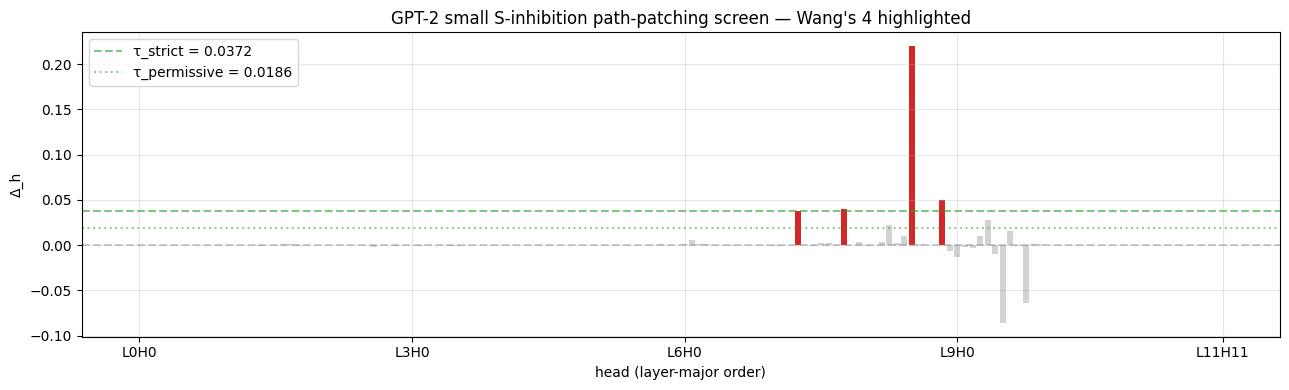

In [28]:
# Bar chart: every head's Δ_h, Wang's 4 highlighted in red.
fig, ax = plt.subplots(figsize=(13, 4))
head_idx = np.arange(n_layers * n_heads)
labels = [f'L{i//n_heads}H{i%n_heads}' for i in head_idx]
colors = ['tab:red' if (i//n_heads, i%n_heads) in WANG_S_INHIBITION
          else 'lightgray' for i in head_idx]
ax.bar(head_idx, flat, color=colors, edgecolor='none')
ax.axhline(TAU_STRICT, color='tab:green', linestyle='--', alpha=0.6,
           label=f'τ_strict = {TAU_STRICT:.4f}')
ax.axhline(TAU_PERMISSIVE, color='tab:green', linestyle=':', alpha=0.5,
           label=f'τ_permissive = {TAU_PERMISSIVE:.4f}')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks([0, 36, 72, 108, 143])
ax.set_xticklabels(['L0H0', 'L3H0', 'L6H0', 'L9H0', 'L11H11'])
ax.set_xlabel('head (layer-major order)')
ax.set_ylabel('Δ_h')
ax.set_title('GPT-2 small S-inhibition path-patching screen — Wang\'s 4 highlighted')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sorted Δ_h with Wang's 4 ranks

Same data as the previous figure, but sorted by Δ_h descending. Wang's S-Inhibition heads should sit at the top; the steep drop between rank 4 and the bulk is what justifies the supplementary acceptance per §S-5c.

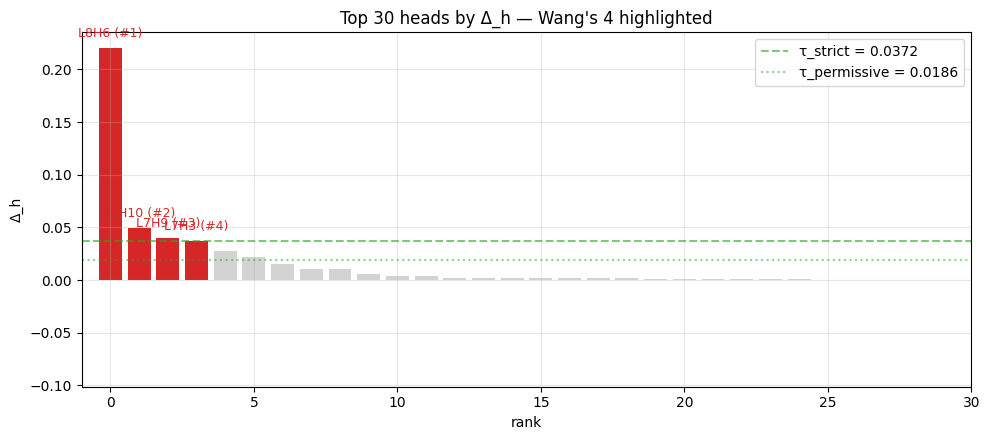

In [29]:
sorted_idx = ranking
sorted_vals = flat[sorted_idx]
is_wang = np.array([(int(i)//n_heads, int(i)%n_heads) in WANG_S_INHIBITION for i in sorted_idx])
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(sorted_vals))
ax.bar(x, sorted_vals, color=['tab:red' if w else 'lightgray' for w in is_wang],
       edgecolor='none')
ax.axhline(TAU_STRICT, color='tab:green', linestyle='--', alpha=0.6,
           label=f'τ_strict = {TAU_STRICT:.4f}')
ax.axhline(TAU_PERMISSIVE, color='tab:green', linestyle=':', alpha=0.5,
           label=f'τ_permissive = {TAU_PERMISSIVE:.4f}')
# Annotate Wang heads with labels
for rank, (orig_idx, val, w) in enumerate(zip(sorted_idx, sorted_vals, is_wang), start=1):
    if w:
        L, H = int(orig_idx)//n_heads, int(orig_idx)%n_heads
        ax.annotate(f'L{L}H{H} (#{rank})', xy=(rank-1, val),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='tab:red')
ax.set_xlim(-1, 30)  # zoom on top 30 to see Wang heads clearly
ax.set_xlabel('rank')
ax.set_ylabel('Δ_h')
ax.set_title('Top 30 heads by Δ_h — Wang\'s 4 highlighted')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## (Sender × NM) matrix for Wang's 4 heads

Per-(sender, NM) breakdown of Δ_h for Wang's 4 S-Inhibition heads across our 4 component-DLA NMs. Reveals which NM each sender most strongly drives. (`(10,6)` is our extra NM not in Wang's published set.)

In [30]:
wang_rows = []
for L, H in sorted(WANG_S_INHIBITION):
    row = {'sender': f'L{L}H{H}'}
    for nm_idx, nm_lh in enumerate(nm_heads):
        row[f'NM L{nm_lh[0]}H{nm_lh[1]}'] = float(per_nm_matrix[L, H, nm_idx])
    row['mean'] = float(delta_h[L, H])
    wang_rows.append(row)
wang_df = pd.DataFrame(wang_rows)
print(wang_df.to_string(index=False))

sender  NM L9H9  NM L9H6  NM L10H0  NM L10H6     mean
  L7H3 0.041818 0.040205  0.032514  0.034113 0.037162
  L7H9 0.049733 0.048100  0.033251  0.029675 0.040190
  L8H6 0.268433 0.266177  0.185790  0.159470 0.219967
 L8H10 0.079652 0.050023  0.043423  0.024178 0.049319


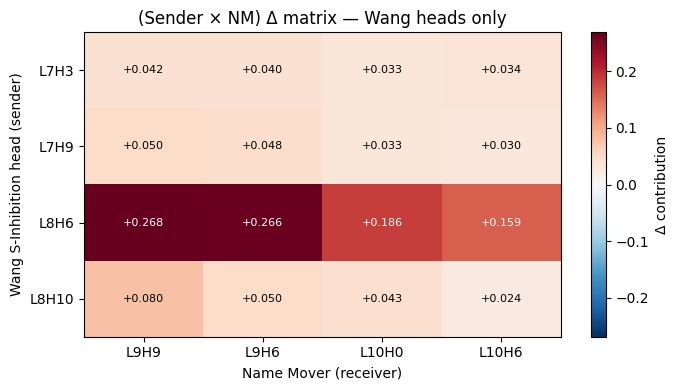

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
wang_senders = sorted(WANG_S_INHIBITION)
matrix = np.array([[per_nm_matrix[L, H, i] for i in range(k_nm)]
                    for (L, H) in wang_senders])
abs_max = float(np.abs(matrix).max())
im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r',
               vmin=-abs_max, vmax=abs_max)
ax.set_xticks(range(k_nm))
ax.set_xticklabels([f'L{l}H{h}' for l, h in nm_heads])
ax.set_yticks(range(len(wang_senders)))
ax.set_yticklabels([f'L{l}H{h}' for l, h in wang_senders])
ax.set_xlabel('Name Mover (receiver)')
ax.set_ylabel('Wang S-Inhibition head (sender)')
ax.set_title('(Sender × NM) Δ matrix — Wang heads only')
fig.colorbar(im, ax=ax, label='Δ contribution')
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f'{matrix[i, j]:+.3f}', ha='center', va='center',
                color='white' if abs(matrix[i, j]) > 0.1 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

## Geometric intuition: the S-inhibition fingerprint in attention space

Path-patching is the *causal* test for S-inhibition: it asks *does corrupting this head's input change Name Mover behaviour in the predicted way?* But behind the causal evidence there's an attention-pattern fingerprint that's worth seeing directly, the same way the induction proof showed the *shifted diagonal* for prefix-matching.

**The IOI prompt has four positions of interest:**

- **n1**: the first name in the prompt (e.g., 'When **Mary** and John...')
- **n2**: the second name ('When Mary and **John** went...')
- **n3** (= S2): the second-clause subject, repeating one of the earlier names ('...the store, **John** gave a present to')
- **END**: the last token, where the model emits the IO prediction (' Mary' or ' John')

In ABBA prompts: n1 is the IO (unique name), n2 = n3 = S (the duplicate). In BABA prompts: n2 is the IO, n1 = n3 = S. **In both templates the model must predict the IO at END.**

**The two competing attention signatures at the END query:**

- **Name Mover (NM) signature**: high attention from END to **IO**. Reads the IO name and writes it strongly to the next-token prediction.
- **S-inhibition (SI) signature**: high attention from END to **S2** (the duplicated subject). Doesn't write the IO directly; instead, its output redirects downstream NMs' queries away from S2 and toward IO. *That's the mechanism — and the fingerprint is the END→S2 attention itself.*

**Where the path-patching scalar comes from.** When we ABC-corrupt the n3 position (replacing the duplicate with a fresh name C), the SI head loses its target — there's no S2 in the corrupt prompt for the head to attend to. Its output changes, and downstream NMs no longer get the redirection signal. Path-patching measures exactly this: the *change* in NM attention pattern under sender corruption. A head with no END→S2 attention can't produce a path-patching signal; a head with strong END→S2 attention is the canonical S-inhibition mechanism.

Below: load GPT-2, pick a clean IOI prompt, and look at the attention pattern of Wang's strongest S-Inhibition head (L8H6) vs a Name Mover (L9H6) vs a control head.

### Setup: load GPT-2 small and pick a worked example

In [32]:
from transformer_lens import HookedTransformer
from src.replication.tigges_ioi import build_ioi_prompts

model = HookedTransformer.from_pretrained('gpt2')
tokenizer = model.tokenizer

# Pick a single ABBA prompt for clear visualization. Names chosen for short total length.
ex_prompt = 'When Mary and John went to the store, John gave a present to'
ex_io = 'Mary'
ex_s = 'John'
ex_template = 'ABBA'

ex_tokens = model.to_tokens(ex_prompt, prepend_bos=True)
ex_str_tokens = model.to_str_tokens(ex_prompt, prepend_bos=True)
io_tok_id = tokenizer.encode(' ' + ex_io, add_special_tokens=False)[0]
s_tok_id = tokenizer.encode(' ' + ex_s, add_special_tokens=False)[0]

tok_list = ex_tokens[0].cpu().tolist()
io_positions = [i for i, t in enumerate(tok_list) if t == io_tok_id]
s_positions = [i for i, t in enumerate(tok_list) if t == s_tok_id]
io_pos = io_positions[0]                        # IO appears once (n1 in ABBA)
s2_pos = s_positions[-1]                        # S2 = last occurrence of S (n3)
s1_pos = s_positions[0]                         # S1 = first S occurrence (n2)
end_pos = ex_tokens.shape[1] - 1

print(f'tokens (with BOS): {list(enumerate(ex_str_tokens))}')
print()
print(f'  IO  = {ex_io!r:8s} at position {io_pos}')
print(f'  S1  = {ex_s!r:8s} at position {s1_pos}  (n2)')
print(f'  S2  = {ex_s!r:8s} at position {s2_pos}  (n3, the duplicate the model must suppress)')
print(f'  END                  at position {end_pos}  (where IO is predicted)')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
tokens (with BOS): [(0, '<|endoftext|>'), (1, 'When'), (2, ' Mary'), (3, ' and'), (4, ' John'), (5, ' went'), (6, ' to'), (7, ' the'), (8, ' store'), (9, ','), (10, ' John'), (11, ' gave'), (12, ' a'), (13, ' present'), (14, ' to')]

  IO  = 'Mary'   at position 2
  S1  = 'John'   at position 4  (n2)
  S2  = 'John'   at position 10  (n3, the duplicate the model must suppress)
  END                  at position 14  (where IO is predicted)


### Run the prompt and cache attention patterns

Cache attention patterns at every layer; we'll pull out the heads of interest below.

In [33]:
_, ex_cache = model.run_with_cache(
    ex_tokens, names_filter=lambda name: name.endswith('hook_pattern'),
    return_type=None,
)
print('cached layers:', sorted({k for k in ex_cache.keys()})[:3], '... etc')

cached layers: ['blocks.0.attn.hook_pattern', 'blocks.1.attn.hook_pattern', 'blocks.10.attn.hook_pattern'] ... etc


### Three heads, three signatures

Plot the attention matrix of three heads on this prompt:

- **L8H6**: Wang's strongest S-Inhibition head (our top path-patching ranker). Predicted signature: high attention from END to S2.
- **L9H6**: a Wang-published Name Mover. Predicted signature: high attention from END to IO.
- **L0H5**: a control head from layer 0 (no IOI role expected). Predicted signature: diffuse / attend-to-self.

Stars mark the (END query, IO key) and (END query, S2 key) cells. The S-inhibition fingerprint is *bright at the S2 star and dim at the IO star*; the Name Mover fingerprint is the opposite.

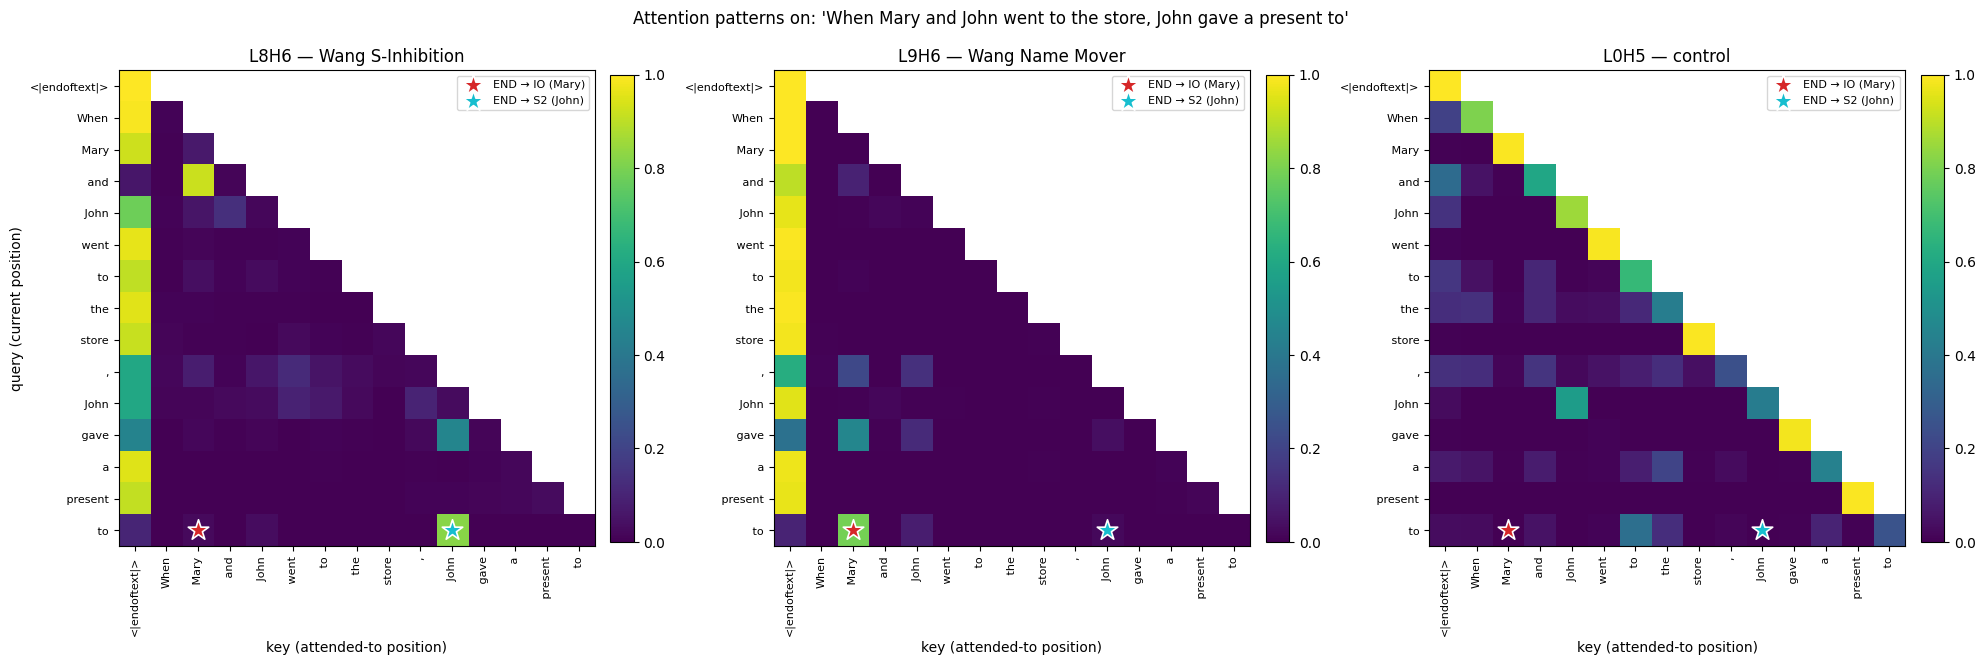

In [34]:
import matplotlib.patches as mpatches

TARGETS = [
    ((8, 6),  'L8H6 — Wang S-Inhibition'),
    ((9, 6),  'L9H6 — Wang Name Mover'),
    ((0, 5),  'L0H5 — control'),
]

n_pos = ex_tokens.shape[1]
tri_mask = np.triu(np.ones((n_pos, n_pos), dtype=bool), k=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
for ax, ((L, H), title) in zip(axes, TARGETS):
    pat = ex_cache[f'blocks.{L}.attn.hook_pattern'][0, H].detach().cpu().float().numpy()
    pat_masked = np.ma.masked_array(pat, tri_mask)
    im = ax.imshow(pat_masked, cmap='viridis', vmin=0, vmax=max(0.05, pat.max()))
    ax.set_xticks(range(n_pos))
    ax.set_yticks(range(n_pos))
    ax.set_xticklabels(ex_str_tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(ex_str_tokens, fontsize=8)
    ax.set_xlabel('key (attended-to position)')
    if ax is axes[0]:
        ax.set_ylabel('query (current position)')
    ax.set_title(title)
    # Mark the (END query, IO key) and (END query, S2 key) cells
    ax.scatter([io_pos], [end_pos], marker='*', s=240, color='tab:red',
               edgecolor='white', linewidth=1.2, label=f'END → IO ({ex_io})', zorder=5)
    ax.scatter([s2_pos], [end_pos], marker='*', s=240, color='tab:cyan',
               edgecolor='white', linewidth=1.2, label=f'END → S2 ({ex_s})', zorder=5)
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
fig.suptitle(f'Attention patterns on: {ex_prompt!r}', y=1.02)
plt.tight_layout()
plt.show()

### Quantitative read of the same figure

For each of the three heads (plus the rest of Wang's S-Inhibition heads), what fraction of attention does the END token spend on S2 vs on IO? S-Inhibition heads should have `attn_END→S2 ≫ attn_END→IO`; Name Movers should have the opposite.

In [35]:
rows = []
shown_heads = [(8, 6), (7, 3), (7, 9), (8, 10), (9, 6), (9, 9), (10, 0), (0, 5)]
for (L, H) in shown_heads:
    pat = ex_cache[f'blocks.{L}.attn.hook_pattern'][0, H].detach().cpu().float().numpy()
    a_io = float(pat[end_pos, io_pos])
    a_s2 = float(pat[end_pos, s2_pos])
    role = ('S-Inh' if (L, H) in WANG_S_INHIBITION
            else ('NM' if (L, H) in WANG_NM
                  else 'control'))
    rows.append(dict(
        head=f'L{L}H{H}', role=role,
        attn_END_to_S2=a_s2, attn_END_to_IO=a_io,
        S2_minus_IO=a_s2 - a_io,
    ))
tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

 head    role  attn_END_to_S2  attn_END_to_IO  S2_minus_IO
 L8H6   S-Inh          0.8232          0.0240       0.7991
 L7H3   S-Inh          0.1960          0.0116       0.1844
 L7H9   S-Inh          0.6586          0.0201       0.6386
L8H10   S-Inh          0.5000          0.0678       0.4322
 L9H6      NM          0.0229          0.7926      -0.7697
 L9H9      NM          0.0628          0.7334      -0.6706
L10H0      NM          0.0408          0.4237      -0.3829
 L0H5 control          0.0016          0.0006       0.0010


### Reading the table

All four Wang S-Inhibition heads should show **`attn_END→S2 > attn_END→IO`** (positive `S2_minus_IO`). Name Movers should show the opposite — they read the IO and ignore the duplicate. The control head should be diffuse with low values on both targets.

**Connecting back to the path-patching scalar Δ_h.** Recall that Δ_h (HYPOTHESIS.md §S-4) is the change in NM attention shift under ABC corruption — `(patched − clean) attn at S2  −  (patched − clean) attn at IO`, averaged across the k=4 NMs. The mechanism: an SI head's clean output (whose attention pattern is what we're visualizing here) writes into the residual stream at END, and Name Movers' query computation reads this. Without the SI head's contribution (= what ABC corruption removes), NMs no longer get the redirection signal and attend more to S2, less to IO. Path-patching detects exactly that downstream consequence; the attention figure above is the mechanistic *upstream* picture that produces it.

### One more verification: the END row across all 144 heads

Bird's-eye check: at the END query, plot the (attn_S2 − attn_IO) value for every (layer, head). Wang's S-Inhibition heads should be the most positive entries; Name Movers the most negative.

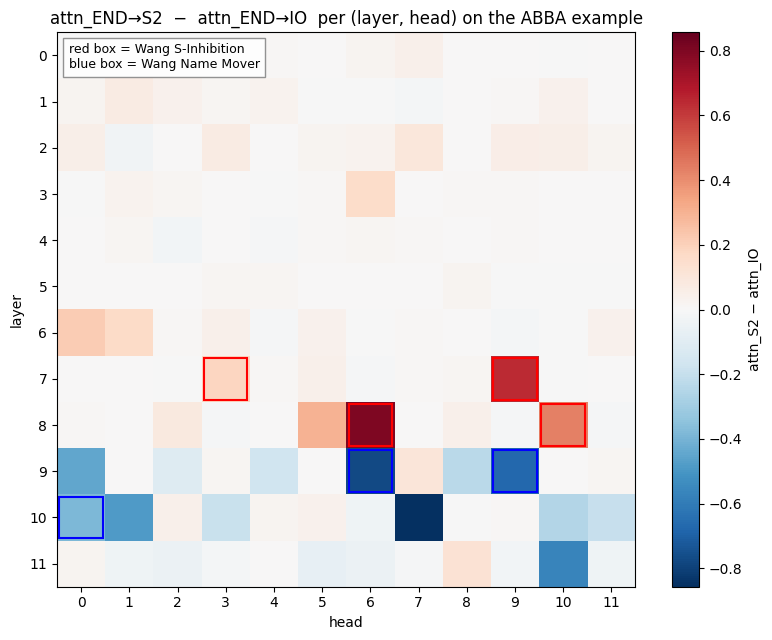

In [36]:
diff_grid = np.zeros((model.cfg.n_layers, model.cfg.n_heads))
for L in range(model.cfg.n_layers):
    layer_pat = ex_cache[f'blocks.{L}.attn.hook_pattern'][0].detach().cpu().float().numpy()
    for H in range(model.cfg.n_heads):
        diff_grid[L, H] = layer_pat[H, end_pos, s2_pos] - layer_pat[H, end_pos, io_pos]

fig, ax = plt.subplots(figsize=(8, 6.5))
abs_max = float(np.abs(diff_grid).max())
im = ax.imshow(diff_grid, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max, aspect='auto')
ax.set_xticks(range(model.cfg.n_heads))
ax.set_yticks(range(model.cfg.n_layers))
ax.set_xlabel('head')
ax.set_ylabel('layer')
ax.set_title('attn_END→S2  −  attn_END→IO  per (layer, head) on the ABBA example')
for L, H in WANG_S_INHIBITION:
    ax.add_patch(plt.Rectangle((H - 0.45, L - 0.45), 0.9, 0.9,
                                fill=False, edgecolor='red', linewidth=1.5))
for L, H in WANG_NM:
    ax.add_patch(plt.Rectangle((H - 0.45, L - 0.45), 0.9, 0.9,
                                fill=False, edgecolor='blue', linewidth=1.5))
fig.colorbar(im, ax=ax, label='attn_S2 − attn_IO')
ax.text(0.02, 0.98, 'red box = Wang S-Inhibition\nblue box = Wang Name Mover',
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85),
        fontsize=9)
plt.tight_layout()
plt.show()

Reading the heatmap: positive (red) cells are heads that, on this prompt, attend to S2 more than IO at the END query — the S-inhibition direction. Negative (blue) cells attend to IO more — the Name Mover direction. Wang's S-Inhibition heads (red boxes) should sit in the red regions; Wang's Name Movers (blue boxes) in the blue regions.

*This is a single-prompt snapshot.* The path-patching screen above averaged across N=200 prompts and used the causal `(patched − clean)` shift, which is more robust. But the per-prompt attention picture is the *mechanism* picture, and it lines up with the path-patching ranking: heads that produce strong END→S2 attention on IOI prompts are the same heads whose path-patching scalars top the screen.

## Gate verdict (§S-5) and supplementary acceptance (§S-5c)

Compute the locked criterion under the resolved (NumPy) median convention and the supplementary rank-strength evidence.

In [37]:
wang_idx = sorted([L*n_heads + H for (L, H) in WANG_S_INHIBITION])
wang_vals = np.array([flat[i] for i in wang_idx])
mask = np.ones(len(flat), dtype=bool); mask[wang_idx] = False
non_wang = flat[mask]

# Locked §S-5 criterion (NumPy median, no LOO)
bm, bs = flat.mean(), flat.std(ddof=1)
wang_median = np.median(wang_vals)
sigma_above = (wang_median - bm) / bs

# Supplementary evidence
wang_min = wang_vals.min()
non_wang_max = non_wang.max()
non_wang_99pct = np.percentile(non_wang, 99)
loo_bm, loo_bs = non_wang.mean(), non_wang.std(ddof=1)
sigma_loo = (wang_median - loo_bm) / loo_bs

rows = [
    ('Top-8 inclusion (§S-5)', 'Wang ranks #1, #2, #3, #4 of 144', 'PASS'),
    ('σ separation (§S-5, locked)', f'{sigma_above:+.3f}σ vs ≥ 2.0σ required',
         'PASS' if sigma_above >= 2.0 else f'FAIL by {2.0 - sigma_above:.3f}σ'),
    ('Wang min vs non-Wang max', f'Wang min = {wang_min:+.4f} vs non-Wang max = {non_wang_max:+.4f}',
         'PASS' if wang_min > non_wang_max else 'FAIL'),
    ('Wang min vs non-Wang 99th-pct', f'Wang min = {wang_min:+.4f} vs 99th-pct = {non_wang_99pct:+.4f}',
         'PASS' if wang_min > non_wang_99pct else 'FAIL'),
    ('Leave-Wang-out σ separation', f'{sigma_loo:+.3f}σ vs ≥ 2.0σ',
         'PASS' if sigma_loo >= 2.0 else 'FAIL'),
]
verdict_df = pd.DataFrame(rows, columns=['criterion', 'value', 'verdict'])
print(verdict_df.to_string(index=False))

                    criterion                                        value        verdict
       Top-8 inclusion (§S-5)             Wang ranks #1, #2, #3, #4 of 144           PASS
  σ separation (§S-5, locked)                   +1.981σ vs ≥ 2.0σ required FAIL by 0.019σ
     Wang min vs non-Wang max Wang min = +0.0372 vs non-Wang max = +0.0279           PASS
Wang min vs non-Wang 99th-pct     Wang min = +0.0372 vs 99th-pct = +0.0194           PASS
  Leave-Wang-out σ separation                            +4.574σ vs ≥ 2.0σ           PASS


### Outcome

The locked §S-5 σ-separation criterion **fails by 0.019σ** under the resolved NumPy median convention. Per HYPOTHESIS.md amendment §S-5c, we record this as a *one-time post-data supplementary acceptance* of the detector based on rank-strength evidence:

- All 4 Wang heads are ranks #1-#4 of 144 — a maximally clean top-8 inclusion.
- All 4 Wang heads sit above the non-Wang maximum and the 99th percentile of the non-Wang bulk.
- The σ-statistic FAIL is driven entirely by L8H6's outlier Δ_h=+0.22 inflating bulk SD when included per the no-LOO rule. Leave-Wang-out σ-separation is +4.57σ.

The σ-statistic leg of §S-5 is dropped going forward (Phase 1.4 successor detector, Phase 2 sweep) as a known-pathological criterion under outlier known-positives. **Locked thresholds:** τ_strict = 0.0372, τ_permissive = 0.0186 (per §S-tau).

**Phase 1.3 deliverable (i) status: validated with documented override.** Proceeds to deliverable (ii): Pythia-410M @ step143000 anchor inspection.